# Quantum Fourier Transform (QFT)
**Notebook:** Circuit implementation, matrix verification, and phase estimation application

## Overview

The **Quantum Fourier Transform (QFT)** is the quantum analogue of the Discrete Fourier Transform (DFT).
It is a key subroutine in many quantum algorithms including **Shor's factoring algorithm** and
**quantum phase estimation**.

### Definition
The QFT maps computational basis states:
$$|j\rangle \mapsto \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i jk/N} |k\rangle$$

### Circuit structure (for $n$ qubits)
The QFT circuit consists of:
1. **Hadamard gate** on the most significant qubit
2. **Controlled phase gates** $R_k = \begin{pmatrix}1&0\\0&e^{2\pi i/2^k}\end{pmatrix}$ from lower qubits
3. Repeat for each qubit
4. **SWAP gates** at the end to reverse qubit order

This gives an $O(n^2)$ gate circuit vs $O(n 2^n)$ for the classical FFT — **exponential speedup**.

### Inverse QFT
The inverse QFT (QFT†) is used in phase estimation. It is the circuit run in reverse with
all phase gates conjugated ($R_k \to R_k^\dagger$).

# 1. QFT

By definition the QFT is the following unitary operation

## $QFT|x\rangle = \frac{1}{2^{n/2}}\sum\limits_{y=0}^{2^n-1}e^{2\pi i \frac{xy}{2^n}} |y\rangle$

Note that here $xy$ is a usual multiplication. Let's unwrap this expression to understand how it can be implemeted in the real circuit. First let's represent $y$  in binary, i.e. $y=y_1 y_2 \dots y_n$ where $y_j$ are either 0 or 1, so

## $y = \sum\limits_{k=1}^{n} 2^{n-k} y_k$

Thus

## $\frac{1}{2^{n/2}}\sum\limits_{y=0}^{2^n-1}e^{2\pi i \frac{xy}{2^n}} |y\rangle = 
\frac{1}{2^{n/2}}\sum\limits_{y=0}^{2^n-1}e^{2\pi ix \left[ \sum\limits_{k=1}^{n} y_k / 2^k \right]} |y_1 y_2 \dots y_n\rangle = 
\frac{1}{2^{n/2}}\sum\limits_{y=0}^{2^n-1}\prod\limits_{k=1}^{n}e^{2\pi ix y_k / 2^k } |y_1 y_2 \dots y_n\rangle = \\ =
\frac{1}{2^{n/2}}\prod\limits_{k=1}^{n}\left( e^{2\pi ix 0 / 2^k } |0\rangle_k + e^{2\pi ix 1 / 2^k } |1\rangle_k \right)= 
\frac{1}{2^{n/2}}\prod\limits_{k=1}^{n}\left( |0\rangle_k + e^{2\pi ix / 2^k } |1\rangle_k \right)= \\ =
\frac{1}{2^{n/2}} \left( |0\rangle_1 + e^{2\pi ix / 2 } |1\rangle_1  \right) \otimes \left( |0\rangle_2 + e^{2\pi ix / 2^2 } |1\rangle_2  \right) \otimes \dots \otimes
\left( |0\rangle_{n-1} + e^{2\pi ix / 2^{n-1} } |1\rangle_{n-1}  \right) \otimes \left( |0\rangle_n + e^{2\pi ix / 2^n } |1\rangle_n  \right)$

We can see that we can construct such a state using single Q-bit gates

## $H|x_k\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle + (-1)^{x_k}|1\rangle \right) \equiv \frac{1}{\sqrt{2}}\left( |0\rangle + e^{2\pi i x_k / 2}|1\rangle \right)$

This is already almost what we want

But we need a phase before the $|1\rangle_k$ state to be equal to $2\pi i x/2^k$. So we have to perform several additional rotations around the $z$-axis

Let's examine the following state

## $\prod\limits_{j=k+1}^{n} C_j ROT_k H |x\rangle_k$

where $C_j ROT_k$ is the controled rotation of the Q-bit $k$ around the $z$ axis on the angle $2\pi/2^k$ with the control Q-bit $j$. We can explicitly rewrite $C_j ROT_k$ in the following form

## $C_j ROT_k |1\rangle_k = e^{2\pi i x_j/2^k} |1\rangle_k$

Which basically means that we add phase $2\pi x_j/2^k$ if the control Q-bit $x_j=1$. 

Noting again that $x/2^n = \sum\limits_{j=1}^{n} x_j / 2^j$

## $\prod\limits_{j=k+1}^{n} C_j ROT_k H |x\rangle_k = \frac{1}{\sqrt{2}} \left( |0\rangle_k + e^{2\pi i \sum\limits_{j=k}^{n}  x_j / 2^j} |1\rangle_k\right) = \frac{1}{\sqrt{2}} \left( |0\rangle_k + e^{2\pi i x / 2^{(n-k)}} |1\rangle_k\right)$

So we get what we wanted, but the Q-bit numbers should be reversed after all the gates, i.e $k \rightarrow n-k$

### Qiskit implemetation of QFT

In [ ]:
def qft(qc, n):
    """Apply QFT to the first n qubits of qc (in-place).

    The QFT is built from two layers:
      1. For each qubit (MSB first): one Hadamard + (n-1-i) controlled-phase gates
         that accumulate the required fractional-binary phase on the |1⟩ amplitude.
      2. A set of SWAP gates that reverses qubit order, because the tensor-product
         derivation produces the output in bit-reversed order.

    Gate count: n Hadamards + n(n-1)/2 CP gates + floor(n/2) SWAPs  →  O(n²) total.
    """
    for i in range(n):
        # Index of the current target qubit, counting from the MSB down
        qb = n - i - 1

        # --- Hadamard ---
        # Maps |x_k⟩ → (|0⟩ + e^{2πi·x_k/2}|1⟩)/√2, creating the first phase bit
        qc.h(qb)

        # --- Controlled-phase rotations from lower qubits ---
        # Each CP(π/2^j) adds e^{iπ·x_{ctrl}/2^j} to the |1⟩ amplitude of qb,
        # building up the full binary fraction e^{2πi·x/2^{n-i}} needed by the QFT.
        for j in range(n - i - 1):
            # angle = π / 2^(j+1)  →  phase increment e^{2πi / 2^(j+2)}
            # control qubit: qb - j - 1  (the next-lower qubit in significance)
            qc.cp(np.pi / np.power(2, j + 1), qb - j - 1, qb)

        # Barrier after each qubit's block for visual clarity in circuit diagrams
        qc.barrier()

    # --- SWAP layer ---
    # The tensor-product construction outputs qubits in bit-reversed order;
    # swapping qubit k with qubit (n-1-k) restores the conventional QFT ordering.
    for qb in range(n // 2):
        qc.swap(qb, n - qb - 1)

In [ ]:
def qft(qc, n):
    """Apply QFT to the first n qubits of qc (in-place)."""
    # Hadamards and controlled phase rotations
    for i in range(n):
        qb = n - i - 1
        qc.h(qb)
        for j in range(n - i - 1):
            # cp = controlled phase gate (renamed from cu1 in Qiskit 1.x)
            qc.cp(np.pi / np.power(2, j + 1), qb - j - 1, qb)
        qc.barrier()
    # Reverse qubit order via swaps (QFT outputs big-endian)
    for qb in range(n // 2):
        qc.swap(qb, n - qb - 1)

n = 3
l = np.power(2, n)   # Hilbert space dimension = 2^n

# Generate a random normalized complex state vector of length 2^n
# (used as the input state to both the circuit and the classical DFT)
init = (rand.rand(2 * l).astype(complex) - 0.5) * 2   # real + imag parts in [-1, 1]
init /= np.linalg.norm(init)                            # normalise to unit length
init = init.reshape(l, 2)
init[:, 1] *= 1j                                        # make second column imaginary
init = init[:, 0] + init[:, 1]                          # combine into complex amplitudes
init

In [ ]:
# --- Classical DFT (analytic reference) ---
# Computes the expected output probabilities so we can verify the circuit below.
# Formula: est[y] = (1/√N) Σ_x  init[x] · e^{2πi·x·y/N}
est = np.arange(l).astype(complex)
for i, y in enumerate(est):
    amp = np.zeros_like(init).astype(complex)
    for j, x in enumerate(init):
        amp[j] = np.exp(2 * np.pi * 1j * i * j / l) * x   # DFT kernel × amplitude
    est[i] = 1 / np.sqrt(l) * np.sum(amp)                  # normalised sum
est

In [ ]:
# Compute QFT analytically (classical DFT) for verification
est = np.arange(l).astype(complex)
for i, y in enumerate(est):
    amp = np.zeros_like(init).astype(complex)
    for j, x in enumerate(init):
        amp[j] = np.exp(2 * np.pi * 1j * i * j / l) * x
    est[i] = 1 / np.sqrt(l) * np.sum(amp)
est

In [ ]:
n = 4
qc1 = QuantumCircuit(n, n)
# Draw the bare QFT circuit (no initial state) so we can inspect the gate structure.
# The circuit shows: n Hadamards, n(n-1)/2 CP gates, and floor(n/2) SWAPs at the end.
# qc1.initialize(init, range(n))   ← commented out: just visualise the skeleton
qft(qc1, n)
qc1.measure(range(n), range(n));
qc1.draw(output='mpl', justify='none')

In [ ]:
# Build the full circuit: initialise to the random state, then apply QFT
qc = QuantumCircuit(n, n)
qc.initialize(init, range(n))   # load the random complex amplitudes generated above
qft(qc, n)                      # apply the QFT circuit in-place
qc.measure(range(n), range(n))  # measure all qubits to obtain output probabilities

In [ ]:
shots = 1024
# Simulate the circuit and convert the counts dict to a (state_index, probability) array
res = backend.run(transpile(qc, backend), shots=shots).result()
res = np.array([[int(key, 2), val / shots] for key, val in res.get_counts().items()])

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
# Circuit output: measured probabilities sorted by state index
ax.plot(res[np.argsort(res[:, 0]), 1], label='Circuit output')
# Analytic reference: |DFT amplitude|² gives the ideal probability for each output state
ax.plot(np.arange(l), np.abs(est) ** 2, label='Classical DFT')
ax.set_xlabel('State index')
ax.set_ylabel('Probability')
ax.set_title('QFT circuit vs Classical DFT (n=3)')
ax.legend()
# If the two curves overlap, the circuit correctly implements the QFT

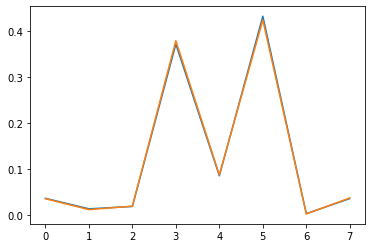

In [200]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
ax.plot(res[np.argsort(res[:,0]),1])
ax.plot(np.arange(l),np.abs(est)**2);

The plots coincide, thus our circuit indeed perofrm QFT

Just to double check let's do the same for $n=5$

In [ ]:
n = 5
l = np.power(2, n)
# Generate random initial state
init = (rand.rand(2 * l).astype(complex) - 0.5) * 2
init /= np.linalg.norm(init)
init = init.reshape(l, 2)
init[:, 1] *= 1j
init = init[:, 0] + init[:, 1]

# Classical DFT
est = np.arange(l).astype(complex)
for i, y in enumerate(est):
    amp = np.zeros_like(init).astype(complex)
    for j, x in enumerate(init):
        amp[j] = np.exp(2 * np.pi * 1j * i * j / l) * x
    est[i] = 1 / np.sqrt(l) * np.sum(amp)

qc = QuantumCircuit(n, n)
qc.initialize(init, range(n))
qft(qc, n)
qc.measure(range(n), range(n))

shots = 4096
res = backend.run(transpile(qc, backend), shots=shots).result()
res = np.array([[int(key, 2), val / shots] for key, val in res.get_counts().items()])

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(res[np.argsort(res[:, 0]), 1], label='Circuit output')
ax.plot(np.arange(l), np.abs(est) ** 2, label='Classical DFT')
ax.legend()
ax.set_xlabel('State index')
ax.set_ylabel('Probability')
ax.set_title('QFT vs Classical DFT (n=5)')

# 2. Quantum phase estimation

We need to estimate a random phase of a single Qbit gate $T=\begin{pmatrix}1 & 0 \\ 0 & e^{i\theta}\end{pmatrix}$

Let's consider the following n + 1 Q-bit state:

$
|\Psi\rangle = H^{\otimes n}|0\rangle \prod \limits_{j=1}^{n} C_jT^j  |1\rangle
$

Where $C_jT^{j}$ is the controled operator $T^j$ with the control Qbit j

So

$|\Psi\rangle = \frac{1}{\sqrt{2^n}}\prod \limits_{j=1}^{n} \left( |0\rangle + e^{ij\theta} |1\rangle \right)|1\rangle$

Let's apply a QFT to the first n Qbits of that state:

## $ |\Psi_F\rangle = \frac{1}{\sqrt{2^n}}\sum\limits_{y=0}^{2^n-1} e^{2\pi i \frac{\Psi y}{2^n}} |y\rangle |\psi\rangle = \frac{1}{2^n}\sum\limits_{j=1}^{n}\sum\limits_{y=0}^{2^n-1} e^{iy\theta} e^{i \frac{2\pi y}{2^n}} |y\rangle |\psi\rangle
$

import pandas as pd
eval_phase = []
real_phase = []
for i in range(10):
    n = 5   # number of counting qubits — more qubits → finer phase resolution (2π/2^n)
    phase = 2 * np.pi * rand.rand()   # random phase θ ∈ [0, 2π) to estimate
    qc = QuantumCircuit(n + 1, n)    # n counting qubits + 1 target qubit

    # --- State preparation ---
    qc.x(n)           # put the target qubit (index n) into |1⟩, the T-gate eigenstate
    qc.h(range(n))    # superpose all counting qubits: |0⟩ → (|0⟩+|1⟩)/√2 each

    # --- Controlled-T^(2^j) gates ---
    # Counting qubit j picks up phase e^{i·θ·2^j} when the target is |1⟩.
    # Together they encode the binary fraction θ/2π into the counting register.
    for j in range(n):
        qc.cp(phase * np.power(2, j), j, n)   # CP(2^j · θ): control=j, target=n

    # --- Inverse QFT on counting register ---
    # Transforms the phase-encoded state back to a computational-basis state
    # that is peaked at the integer closest to θ·2^n / (2π).
    qft(qc, n)   # Note: qft() here acts as the inverse because phase is encoded
                 # in the reverse direction (small-angle on qubit 0)
    qc.measure(range(n), range(n))

    # --- Decode the most-likely measurement outcome ---
    res = backend.run(transpile(qc, backend), shots=4096).result()
    res = np.array([[int(key, 2), value] for key, value in res.get_counts().items()])
    # The measured integer m satisfies m/2^n ≈ 1 - θ/(2π), so θ ≈ 2π(1 - m/2^n)
    eval_phase.append(2 * np.pi * (1 - res[np.argmax(res[:, 1]), 0] / np.power(2, n)))
    real_phase.append(phase)

# --- Summary table ---
df = pd.DataFrame({'Real': real_phase, 'Evaluated': eval_phase})
df.index.name = 'Exp. №'
df['Abs. error'] = np.abs(df['Real'] - df['Evaluated'])
df['Max. error'] = 2 * np.pi * np.ones(len(df)) / np.power(2, n + 1)  # theoretical bound π/2^n
df['Correct'] = df['Abs. error'] < df['Max. error']   # True if within the theoretical bound
df

In [ ]:
import pandas as pd
eval_phase = []
real_phase = []
for i in range(10):
    n = 5
    phase = 2 * np.pi * rand.rand()
    qc = QuantumCircuit(n + 1, n)

    # Prepare eigenstate |1⟩ of the T gate, apply controlled-T^(2^j) for each counting qubit
    qc.x(n)
    qc.h(range(n))
    for j in range(n):
        qc.cp(phase * np.power(2, j), j, n)   # cp = controlled phase (renamed from cu1)

    # Inverse QFT on counting register
    qft(qc, n)
    qc.measure(range(n), range(n))

    res = backend.run(transpile(qc, backend), shots=4096).result()
    res = np.array([[int(key, 2), value] for key, value in res.get_counts().items()])
    eval_phase.append(2 * np.pi * (1 - res[np.argmax(res[:, 1]), 0] / np.power(2, n)))
    real_phase.append(phase)

df = pd.DataFrame({'Real': real_phase, 'Evaluated': eval_phase})
df.index.name = 'Exp. №'
df['Abs. error'] = np.abs(df['Real'] - df['Evaluated'])
df['Max. error'] = 2 * np.pi * np.ones(len(df)) / np.power(2, n + 1)
df['Correct'] = df['Abs. error'] < df['Max. error']
df

The last columns shows whether the difference between the real and estimated phase is smaller than the expected maximum error of the algorithm $1/2^{n+1}$